In [2]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

12101
/media/work/docs/codes/QuCF/scripts-py


In [3]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

In [14]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(mix)

sel_case_ = 1

# --- 1 attractor ---
if sel_case_ == 0:
    F_ = lambda x:  0.5 - x
    tmax_ = 16.0
    x_centers_ = [-0.95 + 0.05 * ii for ii in range(40)]

# --- 1 attractor and an unstable point ---
if sel_case_ == 1:
    F_ = lambda x:  (0.5 - x) * (1.02 - x)
    tmax_ = 16.0
    x_centers_ = [-0.95 + 0.05 * ii for ii in range(40)]

# ------------------------------------------------------------------------------
flag_sim_ = True

nt_ = 9

Nt_ = 1 << nt_

t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

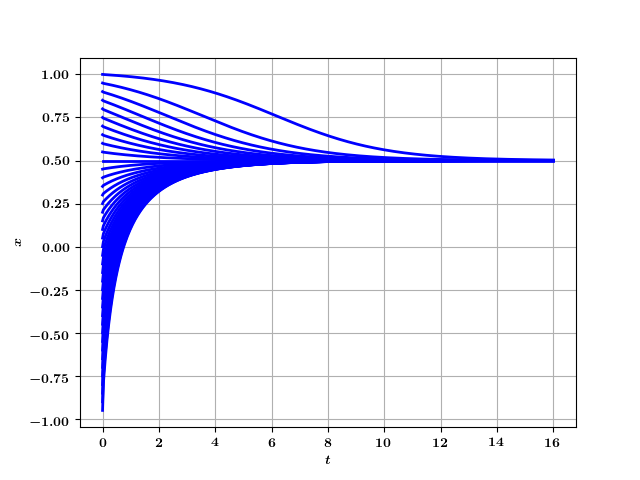

In [15]:
# -----------------------------------------------------------------
# --- Standart method (for reference) ---
# -----------------------------------------------------------------
from scipy.integrate import RK45
mix.reload_module(mix)
def solve_standart(x_center_ref):
    oo = RK45(
        lambda t,x: F_(x), 
        t_[0], 
        [x_center_ref], t_[-1], first_step=dt_, max_step=dt_
    )
    
    sol_ref = np.zeros(Nt_, dtype=float)
    sol_ref[0] = x_center_ref
    Nt_act = 1
    
    oo.step()
    oo.t
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if Nt_act - 1 == Nt_:
            print(oo.t)
        sol_ref[Nt_act-1] = float(oo.y[0])
    return sol_ref
# --------------------------------------------------------------------------

if flag_sim_:
    sol_refs = []
    plt.close()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for i_center in range(len(x_centers_)):
        x_center = x_centers_[i_center]
    
        # --- Solve for the particular x_center ---
        sol_one = solve_standart(x_center)
        sol_refs.append(sol_one)
    
        # --- Plotting ---
        ax.plot(
            t_, sol_one, 
            "b",
            # color=colors_[i_center], 
            linewidth = 2, linestyle='-', 
            # label = "xc = {:0.2f}".format(x_center)
        )
        del x_center
    plt.xlabel('$t$')
    plt.ylabel("$x$")
    # plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Simulations are blocked.")

In [48]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
from scipy.integrate import RK45
mix.reload_module(mix)
def f_to_RK(t, x):
    x1, *_ = x
    f_eqs = [None] * N_nl_
    for i_eq in range(N_nl_):
        f_eqs[i_eq] = FC_eqs_[i_eq](x1)
    return f_eqs
    # return np.array([FC_eqs_[0](x1), FC_eqs_[1](x1)])
# --------------------------------------------------------------
N_nl_ = 4
x_init = 0.3

# --- Form the system ---
FC_eqs_ = [None] * N_nl_
x_init_eqs = [None] * N_nl_
for i_eq in range(1, N_nl_+1):
    FC_eqs_[i_eq-1] = lambda x: i_eq * x**(i_eq-1) * F_(x)
    x_init_eqs[i_eq-1] = x_init**i_eq 

# --- Runge-Kutta solver ---
oo = RK45(
    f_to_RK,
    t_[0], 
    np.array(x_init_eqs), 
    t_[-1], first_step=dt_, max_step=dt_
)

# sol_carleman_ = [None] * Nt_
# sol_carleman_[0] = np.array(x_init_eqs)
# Nt_act = 1

# oo.step()
# oo.t
# while mix.compare_two_strings(oo.status, "running"):
#     oo.step()
#     Nt_act += 1
#     if Nt_act - 1 == Nt_:
#         print(oo.t)
#     sol_carleman_[Nt_act-1] = oo.y.copy()


sol_carleman_ = np.zeros((Nt_, N_nl_))
sol_carleman_[0,:] = np.array(x_init_eqs)
Nt_act = 1

oo.step()
oo.t
while mix.compare_two_strings(oo.status, "running"):
    oo.step()
    Nt_act += 1
    if Nt_act - 1 == Nt_:
        print(oo.t)
    sol_carleman_[Nt_act-1,:] = oo.y.copy()

# ---------------------


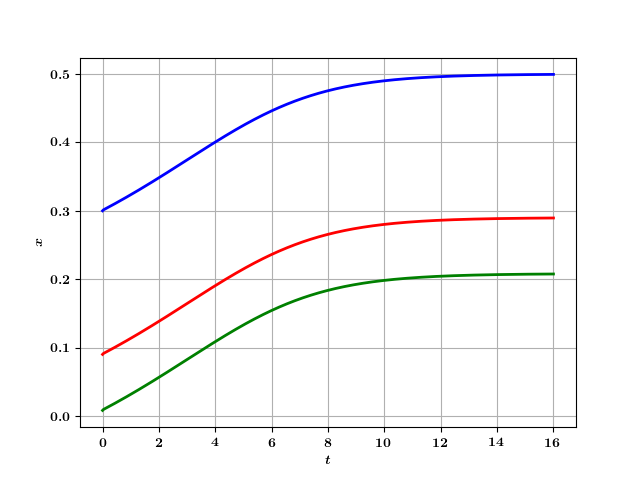

In [51]:
if flag_sim_:
    plt.close()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(
        t_, sol_carleman_[:,0], 
        "b",
        # color=colors_[i_center], 
        linewidth = 2, linestyle='-', 
        # label = "xc = {:0.2f}".format(x_center)
    )
    ax.plot(
        t_, sol_carleman_[:,1], 
        "r",
        # color=colors_[i_center], 
        linewidth = 2, linestyle='-', 
        # label = "xc = {:0.2f}".format(x_center)
    )
    ax.plot(
        t_, sol_carleman_[:,3], 
        "g",
        # color=colors_[i_center], 
        linewidth = 2, linestyle='-', 
        # label = "xc = {:0.2f}".format(x_center)
    )
    plt.xlabel('$t$')
    plt.ylabel("$x$")
    # plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Simulations are blocked.")

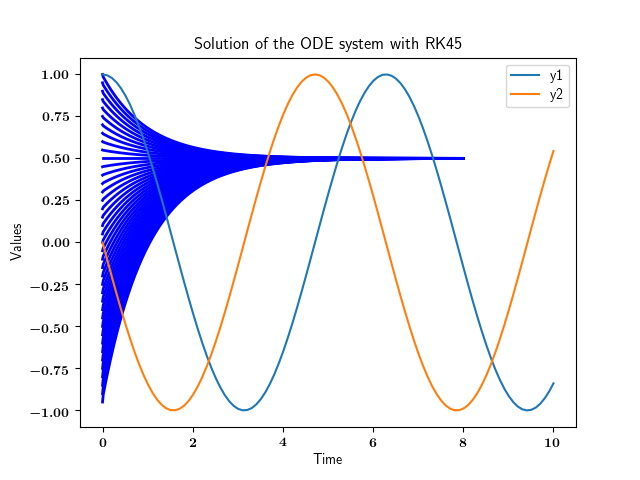

In [12]:
import numpy as np
from scipy.integrate import RK45
import matplotlib.pyplot as plt

# Define the system of ODEs
def f(t, y):
    y1, y2 = y
    return [y2, -y1]

# Initial conditions
y0 = [1.0, 0.0]  # y1(0)=1, y2(0)=0
t0 = 0.0
t1 = 10.0

# Create RK45 solver
solver = RK45(f, t0, y0, t1, max_step=0.1)

# Store results
ts = []
ys = []

while solver.status == 'running':
    solver.step()
    ts.append(solver.t)
    ys.append(solver.y.copy())

# Convert results to arrays
ts = np.array(ts)
ys = np.array(ys)

# Plot the results
plt.plot(ts, ys[:, 0], label='y1')
plt.plot(ts, ys[:, 1], label='y2')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Solution of the ODE system with RK45')
plt.legend()
plt.grid()
plt.show()